# CMAPSS Turbofan Engine Predictive Maintenance
## Exploratory Data Analysis

**Dataset:** NASA Commercial Modular Aero-Propulsion System Simulation (CMAPSS)  
**Subset:** FD001 (single fault mode, single operating condition)  
**Goal:** Predict Remaining Useful Life (RUL) of turbofan engines from sensor readings

### Background
Predictive maintenance aims to predict equipment failure before it occurs using sensor data, enabling maintenance to be scheduled only when needed. 
This is more efficient than time-based preventive maintenance and safer than reactive maintenance.

The target variable is Remaining Useful Life (RUL) which is the number of cycles remaining before an engine fails. 
A maintenance engineer can use this to schedule intervention at the right time, avoiding both unnecessary downtime and unexpected failures.

### Dataset Structure
Each row represents one flight cycle for one engine. The dataset contains:
- `engine_id` - unique identifier for each engine
- `cycle` - flight number (engines run until failure)
- `setting_1`, `setting_2`, `setting_3` - operational condition variables
- `sensor_1` through `sensor_21` - 21 physical sensor measurements

FD001 contains a single operating condition, meaning the three setting variables remain nearly constant throughout. 
This makes it the simplest of the four subsets and a good starting point before tackling FD003/FD004.

## 1. Data Loading
Loading the FD001 training set and assigning column names based on the NASA dataset documentation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The dataset has no headers so the column names are defined based on the NASA documentation
column_names = [
    'engine_id',      # which engine
    'cycle',          # time step - flight number
    'setting_1',      # operational setting 1
    'setting_2',      # operational setting 2
    'setting_3',      # operational setting 3
    'sensor_1',       # 21 sensor measurements
    'sensor_2',
    'sensor_3',
    'sensor_4',
    'sensor_5',
    'sensor_6',
    'sensor_7',
    'sensor_8',
    'sensor_9',
    'sensor_10',
    'sensor_11',
    'sensor_12',
    'sensor_13',
    'sensor_14',
    'sensor_15',
    'sensor_16',
    'sensor_17',
    'sensor_18',
    'sensor_19',
    'sensor_20',
    'sensor_21'
]

# Load the training data for FD001 to start
# sep='\s+' handles the whitespace-separated format
df = pd.read_csv(
    '../CMAPSSData/train_FD001.txt',
    sep='\s+',
    header=None,
    names=column_names
)

# Sanity check
print(df.shape)
df.head(10)

(20631, 26)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


### Observations
- setting_1, setting_2 stay near zero with minimal variation, confirming FD001 operates under a single condition
- setting_3 is constant at 100.0 across all rows with no variation
- Sensor values appear stable in early cycles which is expected for healthy engines

## 2. Engine Lifetime Analysis
Before calculating RUL, we first examine how long each engine runs before failure.
This tells us how much variation exists in engine lifetimes and sets expectations 
for what our model needs to handle.

Number of engines: 100

Cycles per engine (min, mean, max):
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


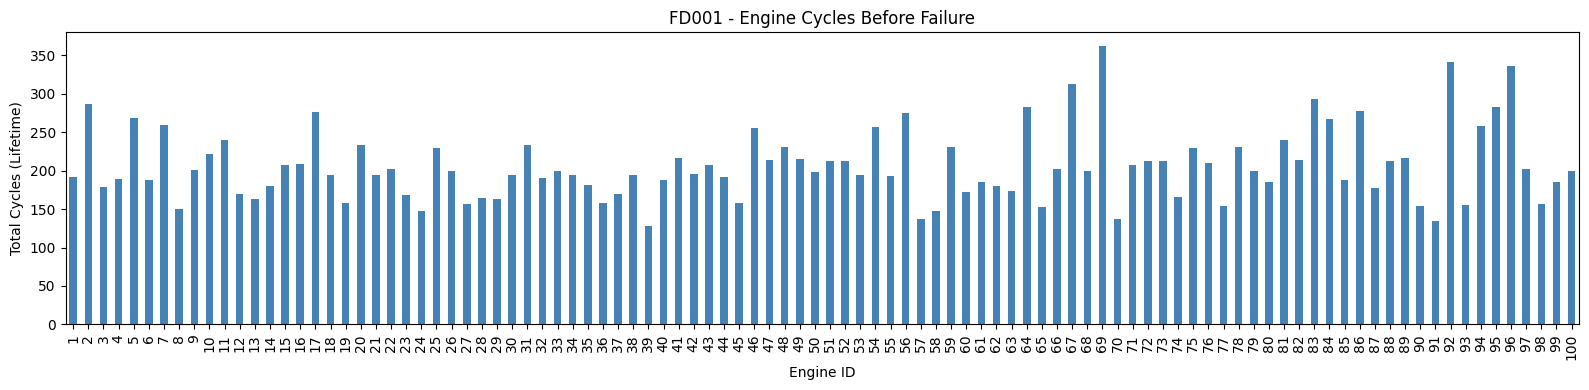

In [2]:
# How many unique engines are there
print("Number of engines:", df['engine_id'].nunique())

# How many cycles does each engine run before failure
cycles_per_engine = df.groupby('engine_id')['cycle'].max()
print("\nCycles per engine (min, mean, max):")
print(cycles_per_engine.describe())

# Plot the distribution of engine lifetimes
plt.figure(figsize=(16, 4))
cycles_per_engine.plot(kind='bar', color='steelblue')
plt.xlabel('Engine ID')
plt.ylabel('Total Cycles (Lifetime)')
plt.title('FD001 - Engine Cycles Before Failure')
plt.tight_layout()
plt.show()

### Observations
- FD001 contains 100 engines with lifetimes ranging from 128 to 362 cycles
- Mean lifetime: ~206 cycles, median: ~199 cycles
- The distribution shows meaningful variation. Engines do not all degrade at the same rate, which means the model must learn degradation patterns from sensor data rather than simply learning a typical lifespan
- Engine 69 is a notable outlier at ~362 cycles

## 3. RUL Calculation
The training data does not include RUL directly so it must be derived. 
Since we know each engine runs until failure, RUL at any given cycle is:

RUL = max_cycle - current_cycle

Where max_cycle is the last recorded cycle for that engine which is its failure point.

In [3]:
# Calculate RUL for each row in the training data
max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

# Merge max cycle back into the main dataframe
df = df.merge(max_cycles, on='engine_id')

# RUL is how many cycles are left until failure
df['RUL'] = df['max_cycle'] - df['cycle']

# Drop the max_cycle column since we don't need it anymore
df = df.drop(columns=['max_cycle'])

# Verify it looks right - now showing cycle, RUL, and total lifetime together
df['total_lifetime'] = df.groupby('engine_id')['cycle'].transform('max')

print(df[['engine_id', 'cycle', 'RUL', 'total_lifetime']].head(10))
print("\nEngine 1 total lifetime:", df[df['engine_id'] == 1]['total_lifetime'].iloc[0])
print("Engine 1 RUL at cycle 1:", df[df['engine_id'] == 1]['RUL'].iloc[0])


   engine_id  cycle  RUL  total_lifetime
0          1      1  191             192
1          1      2  190             192
2          1      3  189             192
3          1      4  188             192
4          1      5  187             192
5          1      6  186             192
6          1      7  185             192
7          1      8  184             192
8          1      9  183             192
9          1     10  182             192

Engine 1 total lifetime: 192
Engine 1 RUL at cycle 1: 191


### Verification
- Engine 1 total lifetime = 192 cycles
- For every row: RUL + cycle = total_lifetime, confirming correct calculation

## 4. Sensor Analysis

### 4.1 Variance Analysis
Not all 21 sensors carry useful information. Sensors with near-zero variance do not change over time and therefore cannot help predict degradation. 
We calculate standard deviation across all readings for each sensor to identify and remove uninformative sensors before deeper analysis.

Sensor standard deviations (sorted):
sensor_1      0.0000
sensor_10     0.0000
sensor_19     0.0000
sensor_18     0.0000
sensor_16     0.0000
sensor_5      0.0000
sensor_6      0.0014
sensor_15     0.0375
sensor_8      0.0710
sensor_13     0.0719
sensor_21     0.1083
sensor_20     0.1807
sensor_11     0.2671
sensor_2      0.5001
sensor_12     0.7376
sensor_7      0.8851
sensor_17     1.5488
sensor_3      6.1311
sensor_4      9.0006
sensor_14    19.0762
sensor_9     22.0829
dtype: float64


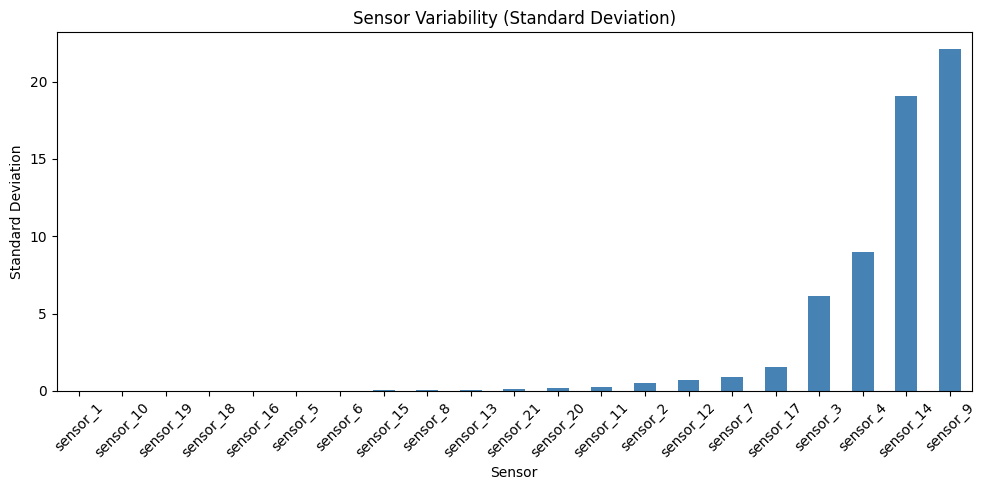

In [4]:
# Drop non-sensor columns
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]

# Calculate standard deviation for each sensor across the whole dataset
sensor_std = df[sensor_cols].std().sort_values()

print("Sensor standard deviations (sorted):")
print(sensor_std.round(4))

# Plot
plt.figure(figsize=(10, 5))
sensor_std.plot(kind='bar', color='steelblue')
plt.title('Sensor Variability (Standard Deviation)')
plt.xlabel('Sensor')
plt.ylabel('Standard Deviation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations
7 sensors were dropped for near-zero variance:
sensor_1, sensor_5, sensor_6, sensor_10, sensor_16, sensor_18, sensor_19

- These sensors show no meaningful variation across the entire dataset and carry no predictive signal. Dropping them reduces noise and simplifies the amount of features.
- High variance alone does not guarantee a sensor is useful for predicting degradation. A sensor could vary randomly without trending toward failure. 
- The next step examines whether remaining sensors show meaningful degradation trends.

In [5]:
# Drop total_lifetime now that verification is done
df = df.drop(columns=['total_lifetime'])

# Identify and drop sensors with near-zero variance
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
sensor_std = df[sensor_cols].std()

# Threshold of 0.01 to catch sensor_6 as well
low_variance_sensors = sensor_std[sensor_std < 0.01].index.tolist()
print("Dropping low variance sensors:", low_variance_sensors)

df = df.drop(columns=low_variance_sensors)

# Check what sensors we have left
remaining_sensors = [col for col in df.columns if col.startswith('sensor')]
print("Remaining sensors:", remaining_sensors)
print("DataFrame shape after dropping:", df.shape)
df.head(10)

Dropping low variance sensors: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Remaining sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
DataFrame shape after dropping: (20631, 20)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187
5,1,6,-0.0043,-0.0001,100.0,642.10,1584.47,1398.37,554.67,2388.02,9049.68,47.16,521.68,2388.03,8132.85,8.4108,391,38.98,23.3669,186
6,1,7,0.0010,0.0001,100.0,642.48,1592.32,1397.77,554.34,2388.02,9059.13,47.36,522.32,2388.03,8132.32,8.3974,392,39.10,23.3774,185
7,1,8,-0.0034,0.0003,100.0,642.56,1582.96,1400.97,553.85,2388.00,9040.80,47.24,522.47,2388.03,8131.07,8.4076,391,38.97,23.3106,184
8,1,9,0.0008,0.0001,100.0,642.12,1590.98,1394.80,553.69,2388.05,9046.46,47.29,521.79,2388.05,8125.69,8.3728,392,39.05,23.4066,183
9,1,10,-0.0033,0.0001,100.0,641.71,1591.24,1400.46,553.59,2388.05,9051.70,47.03,521.79,2388.06,8129.38,8.4286,393,38.95,23.4694,182


### 4.2 Degradation Trends - Single Engine
We plot all 14 remaining sensors over the lifetime of a single engine to visually identify which sensors show meaningful trends toward failure (marked by red dashed line).
Sensors of interest will show a consistent upward or downward trend rather than random noise around a stable value.

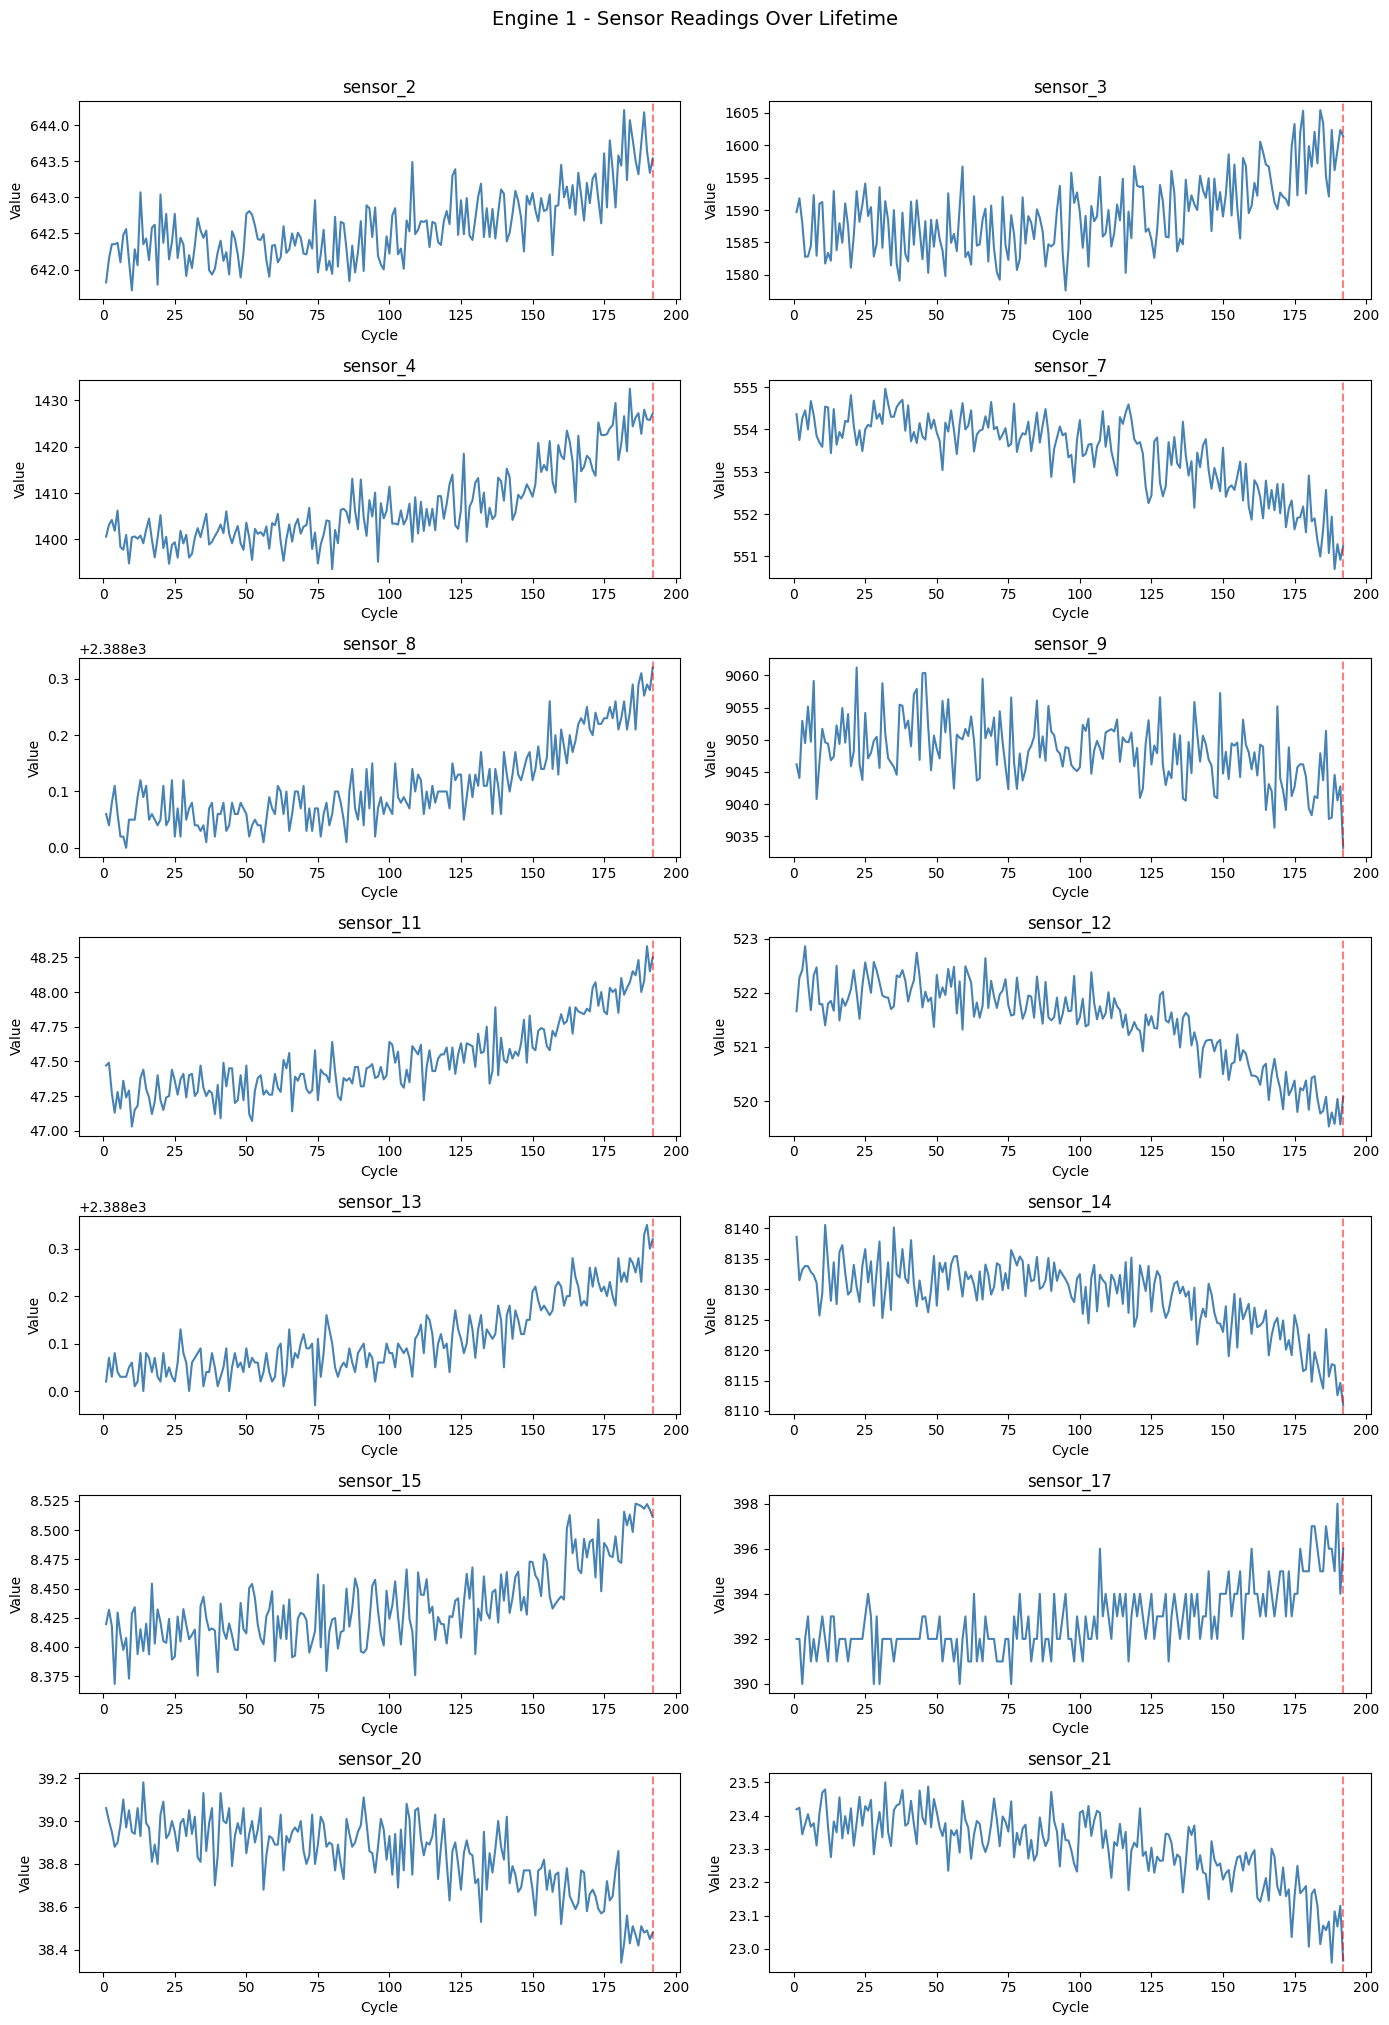

In [6]:
# Starting with just engine 1
engine_id = 1
engine_data = df[df['engine_id'] == engine_id].sort_values('cycle')

remaining_sensors = [col for col in df.columns if col.startswith('sensor')]

# Plot all remaining sensors over the engine's lifetime
fig, axes = plt.subplots(7, 2, figsize=(14, 20))
axes = axes.flatten()

for i, sensor in enumerate(remaining_sensors):
    axes[i].plot(engine_data['cycle'], engine_data[sensor], color='steelblue')
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Value')
    # Add a vertical line at the last cycle to mark failure
    axes[i].axvline(x=engine_data['cycle'].max(), color='red', linestyle='--', alpha=0.5, label='Failure')

plt.suptitle(f'Engine {engine_id} - Sensor Readings Over Lifetime', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Observations
The following sensors show meaningful trends throughout the engine's lifetime:
sensor_2, sensor_3, sensor_4, sensor_7, sensor_8, sensor_11, sensor_12, sensor_13, sensor_14, sensor_15, sensor_17, sensor_21

- Upward trends can indicate rising measurements in features such as temperature or pressure that would correlate with a failing engine.
- Similarly, downward trends can indicate decreasing measurements in features such as efficiency metrics.

- Note: Sensor 20 has a sharp drop at the end while remaining relatively flat throughout the engine's lifetime. 
- This is weaker than the other sensors, but does not seem weak enough to remove.

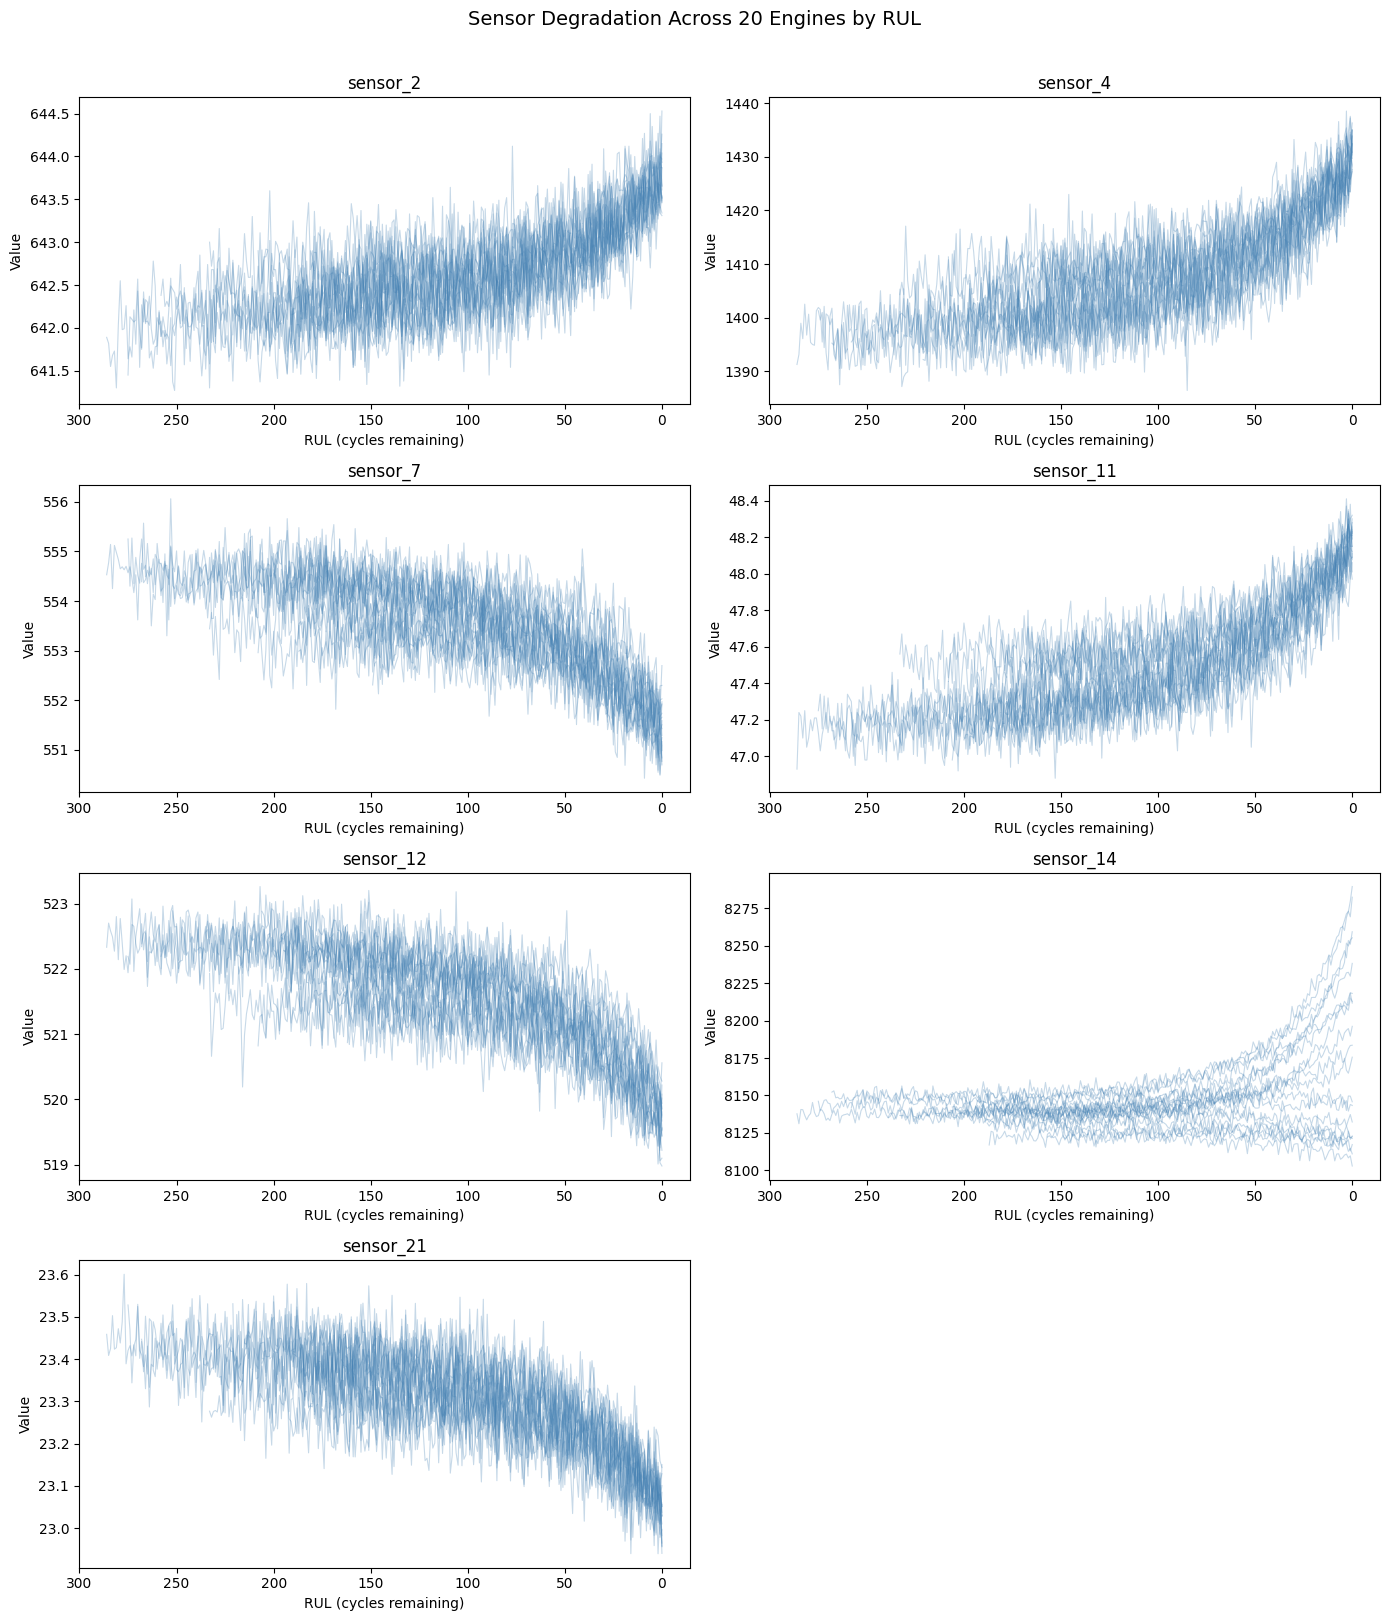

In [7]:
# Selecting a subset of the clearest sensors to keep the plot readable
key_sensors = ['sensor_2', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_21']

# Plot against RUL instead of cycle to align all engines by how far they are from failure instead of how long they have been running
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

# Sample 20 engines so the plot does not get too crowded
sample_engines = df['engine_id'].unique()[:20]

for i, sensor in enumerate(key_sensors):
    for engine in sample_engines:
        engine_data = df[df['engine_id'] == engine].sort_values('RUL', ascending=False)
        axes[i].plot(engine_data['RUL'], engine_data[sensor], alpha=0.3, linewidth=0.8, color='steelblue')
    
    axes[i].set_title(sensor)
    axes[i].set_xlabel('RUL (cycles remaining)')
    axes[i].set_ylabel('Value')
    # Flip x axis so time moves left to right toward failure
    axes[i].invert_xaxis()

# Hide the unused last subplot
axes[-1].set_visible(False)

plt.suptitle('Sensor Degradation Across 20 Engines by RUL', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Observations
The following sensors show high density throughout, indicating high consistency across all engines.
sensor_2, sensor_4, sensor_7, sensor_11, sensor_12, sensor_21

- Sensor 14 remains relatively flat before fanning out at the end. This shows that the degradation signal appears late with differing magnitudes.
- Therefore, sensor 14 is not good for predictive maintenance, due to lack of early warning.

### 4.2 Correlation Analysis
We plot the correlation matrix to identify which sensors are redundant with each other.
If two sensors are highly correlated, feeding both into a model will add noise without extra information.

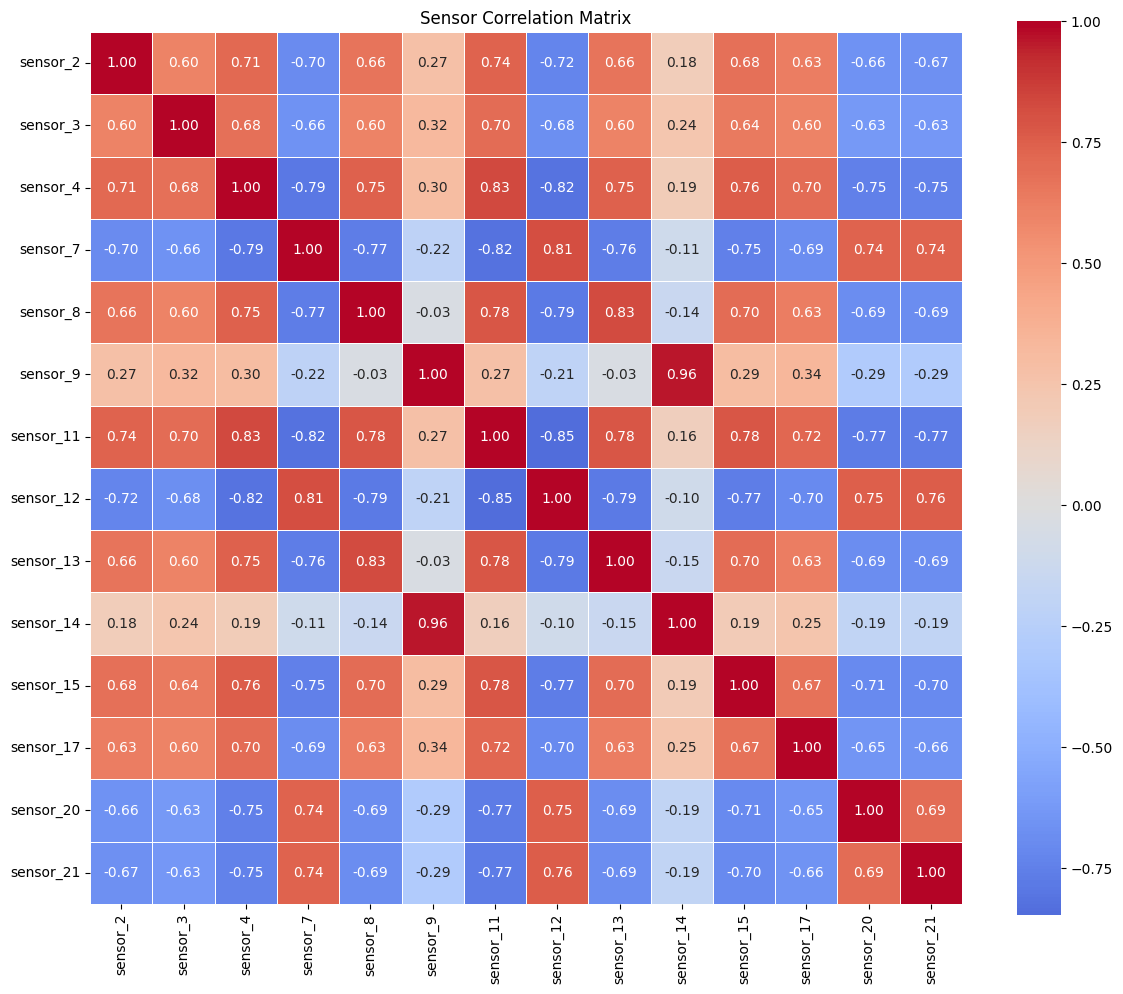

In [8]:
# Select remaining sensor columns
remaining_sensors = [col for col in df.columns if col.startswith('sensor')]

# Calculate correlation matrix
corr_matrix = df[remaining_sensors].corr()

# Plot as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,          # show correlation values in each cell
    fmt='.2f',           # round to 2 decimal places
    cmap='coolwarm',     # blue = negative correlation, red = positive
    center=0,            # center the colorscale at zero
    square=True,
    linewidths=0.5
)
plt.title('Sensor Correlation Matrix')
plt.tight_layout()
plt.show()

### Observations
- Sensors 9 and 14 stand out as being highly correlated at 0.96. 
- Earlier, sensor 14 was also noted for providing an inconsistent signal in degradation analysis. Therefore, dropping sensor 14 makes sense.

In [9]:
# Drop sensor 14
df = df.drop(columns=['sensor_14'])

remaining_sensors = [col for col in df.columns if col.startswith('sensor')]
print("Final sensor set:", remaining_sensors)
print("Sensors remaining:", len(remaining_sensors))
print("DataFrame shape:", df.shape)

Final sensor set: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Sensors remaining: 13
DataFrame shape: (20631, 19)


## 4.3 RUL Analysis
We plot the distribution of RUL values in the remaining sensors to examine the shape of our target variable. 

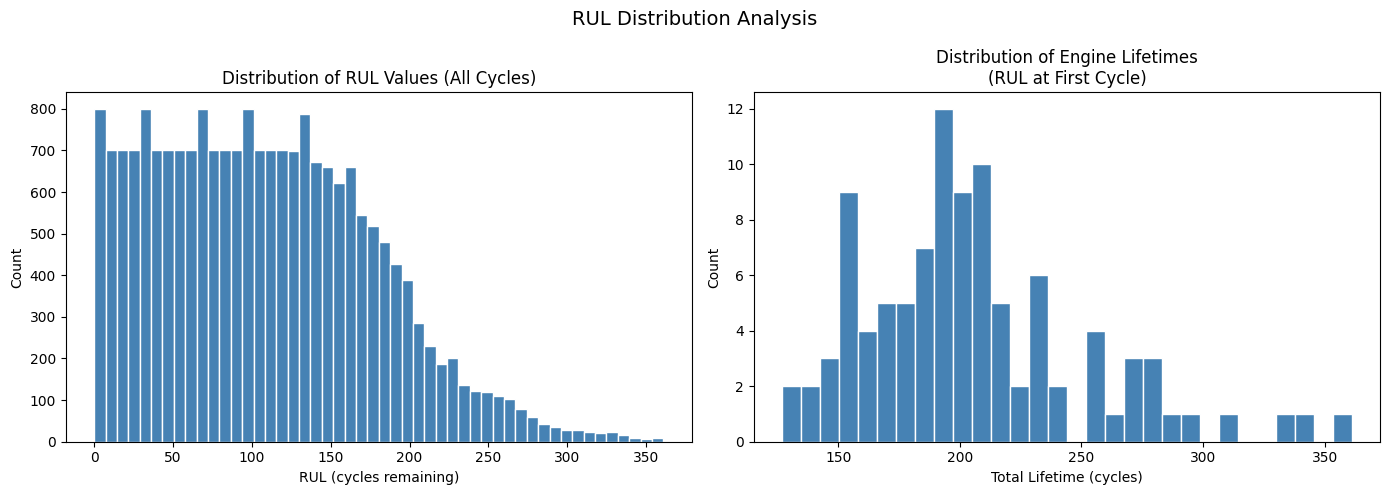

RUL Summary Statistics:
count    20631.0
mean       107.8
std         68.9
min          0.0
25%         51.0
50%        103.0
75%        155.0
max        361.0
Name: RUL, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: distribution of all RUL values in the training set
axes[0].hist(df['RUL'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of RUL Values (All Cycles)')
axes[0].set_xlabel('RUL (cycles remaining)')
axes[0].set_ylabel('Count')

# Right plot: distribution of RUL at just the first cycle of each engine
first_cycles = df[df['cycle'] == 1]['RUL']
axes[1].hist(first_cycles, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Engine Lifetimes\n(RUL at First Cycle)')
axes[1].set_xlabel('Total Lifetime (cycles)')
axes[1].set_ylabel('Count')

plt.suptitle('RUL Distribution Analysis', fontsize=14)
plt.tight_layout()
plt.show()

# Print summary statistics
print("RUL Summary Statistics:")
print(df['RUL'].describe().round(1))

### Observations
- The left plot (distribution of RUL values) is right-skewed, due to having more data from engines closer to failure.
- This means that a prediction model would become more accurate at predicting engine RUL late in its lifetime rather than early.
- Since we are trying to meaningfully predict RUL, we want to focus our model on the data when an engine is closer to the end of its lifetime rather than early when it is healthy.
- Therefore, we can apply a piecewise linear cap on RUL to ignore high values of RUL when an engine is healthy.
- We can choose a cap value of 125 based on the previous degradation analysis where most sensors started to visibly degrade at 125.

Max RUL after capping: 125
Min RUL after capping: 0


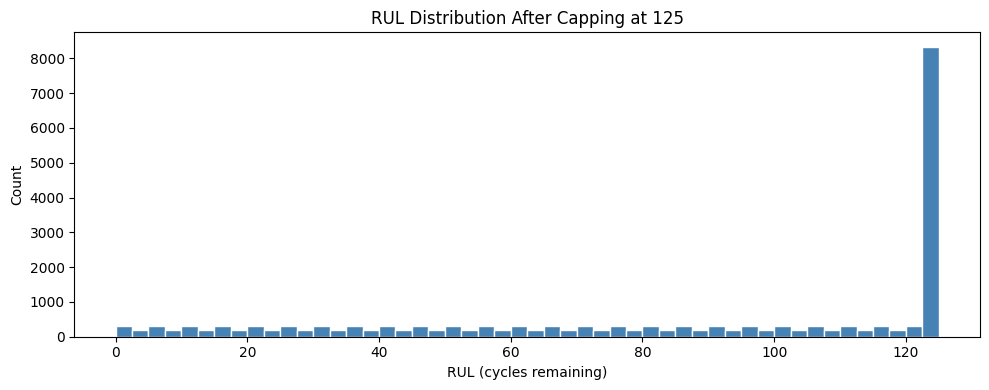

In [11]:
# Apply piecewise linear cap to RUL
# Engines with more than 125 cycles remaining are labeled as 125
cap = 125
df['RUL'] = df['RUL'].clip(upper=cap)

# Verify the cap
print("Max RUL after capping:", df['RUL'].max())
print("Min RUL after capping:", df['RUL'].min())

# Plot the new RUL distribution
plt.figure(figsize=(10,4))
plt.hist(df['RUL'], bins=50, color='steelblue', edgecolor='white')
plt.title('RUL Distribution After Capping at 125')
plt.xlabel('RUL (cycles remaining)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Observations
- Many of the RUL values exist higher than our proposed cap of 125.
- This is due to a mathematical consequence of every engine having low RUL data points but not necessarily high RUL data points.
- The model will see many values labeled at 125 even though it represents engines at different health states.
- This tradeoff is acceptable due to higher values of RUL not mattering for predictive maintenance.

In [12]:
import os

# Save the final cleaned dataframe to data folder
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/fd001_cleaned.csv', index=False)
print("Saved cleaned dataframe to data/fd001_cleaned.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Saved cleaned dataframe to data/fd001_cleaned.csv
Shape: (20631, 19)
Columns: ['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL']


## Summary
Starting from 21 raw sensors we reduced to a final set of 13 informative sensors through three steps:

**Variance filtering** - removed 7 sensors with near-zero variance

**Redundancy removal** - removed sensor 14 due to 0.96 correlation with sensor 9 and inconsistent signal

**RUL capping** - applied a cap of 125 cycles to focus model training on the degradation zone that matters practically

**Final feature set** - 13 sensors + 3 operational settings + cycle

**Final dataframe shape:** - 20,631 rows × 19 columns